# Final model selection

This notebook compares random forest and gradient boosting after separately
optimizing their decision thresholds on validation data.

The final model is selected using the estimated validation cost. The untouched
test set is used only for the final evaluation.

In [10]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_PATH = PROJECT_ROOT / "src"

if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

In [11]:
FIGURE_DIRECTORY = PROJECT_ROOT / "reports" / "figures"
FIGURE_DIRECTORY.mkdir(parents=True, exist_ok=True)

In [12]:
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split

from predictive_maintenance.data import load_data
from predictive_maintenance.evaluate import (
    calculate_metrics,
    find_cost_optimal_threshold,
)
from predictive_maintenance.features import create_features
from predictive_maintenance.train import (
    create_gradient_boosting_model,
    create_random_forest_model,
    split_data,
)

In [13]:
df = load_data()
X, y = create_features(df)

X_train_full, X_test, y_train_full, y_test = split_data(X, y)

X_train, X_validation, y_train, y_validation = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.25,
    random_state=42,
    stratify=y_train_full,
)

print(f"Training observations: {len(X_train)}")
print(f"Validation observations: {len(X_validation)}")
print(f"Test observations: {len(X_test)}")

Loading local dataset from /Users/alexanderkorolev/Desktop/predictive-maintenance-ai4i/data/raw/ai4i2020.csv
Training observations: 6000
Validation observations: 2000
Test observations: 2000


In [14]:
models = {
    "Random forest": create_random_forest_model(X_train),
    "Gradient boosting": create_gradient_boosting_model(X_train),
}

for model in models.values():
    model.fit(X_train, y_train)

In [15]:
FALSE_POSITIVE_COST = 100.0
FALSE_NEGATIVE_COST = 5000.0

validation_rows = []
optimized_thresholds = {}

for model_name, model in models.items():
    validation_probabilities = model.predict_proba(
        X_validation
    )[:, 1]

    best_threshold, threshold_results = find_cost_optimal_threshold(
        target=y_validation,
        probabilities=validation_probabilities,
        false_positive_cost=FALSE_POSITIVE_COST,
        false_negative_cost=FALSE_NEGATIVE_COST,
    )

    optimized_thresholds[model_name] = best_threshold

    best_result = threshold_results.loc[
        threshold_results["total_cost"].idxmin()
    ]

    validation_rows.append(
        {
            "model": model_name,
            "threshold": best_threshold,
            "false_positive": int(best_result["false_positive"]),
            "false_negative": int(best_result["false_negative"]),
            "true_positive": int(best_result["true_positive"]),
            "total_cost": float(best_result["total_cost"]),
        }
    )

validation_results = pd.DataFrame(validation_rows)
validation_results.set_index("model").round(2)

,threshold,false_positive,false_negative,true_positive,total_cost
model,,,,,
Random forest,0.08,208,4,64,40800.0
Gradient boosting,0.07,228,2,66,32800.0


In [16]:
best_model_name = validation_results.loc[
    validation_results["total_cost"].idxmin(),
    "model",
]

best_model = models[best_model_name]
best_threshold = optimized_thresholds[best_model_name]

print(f"Selected model: {best_model_name}")
print(f"Selected threshold: {best_threshold:.2f}")

Selected model: Gradient boosting
Selected threshold: 0.07


In [17]:
test_rows = []
test_predictions = {}

for model_name, model in models.items():
    threshold = optimized_thresholds[model_name]
    probabilities = model.predict_proba(X_test)[:, 1]
    predictions = (probabilities >= threshold).astype(int)

    metrics = calculate_metrics(
        model,
        X_test,
        y_test,
        threshold=threshold,
    )

    false_positive = int(
        ((predictions == 1) & (y_test.to_numpy() == 0)).sum()
    )
    false_negative = int(
        ((predictions == 0) & (y_test.to_numpy() == 1)).sum()
    )

    total_cost = (
        false_positive * FALSE_POSITIVE_COST
        + false_negative * FALSE_NEGATIVE_COST
    )

    test_predictions[model_name] = predictions

    test_rows.append(
        {
            "model": model_name,
            "threshold": threshold,
            **metrics,
            "false_positive": false_positive,
            "false_negative": false_negative,
            "total_cost": total_cost,
        }
    )

test_results = pd.DataFrame(test_rows)
test_results.set_index("model").round(3)

,threshold,accuracy,precision,recall,f1_score,pr_auc,false_positive,false_negative,total_cost
model,,,,,,,,,
Random forest,0.08,0.908,0.259,0.912,0.404,0.726,177,6,47700.0
Gradient boosting,0.07,0.908,0.261,0.941,0.409,0.769,181,4,38100.0


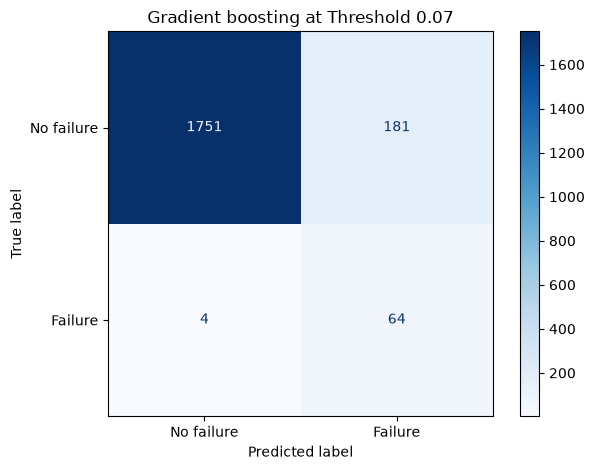

In [ ]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    test_predictions[best_model_name],
    display_labels=["No failure", "Failure"],
    cmap="Blues",
)

plt.title(
    f"{best_model_name} at Threshold {best_threshold:.2f}"
)
plt.tight_layout()
plt.savefig(
    FIGURE_DIRECTORY / "final_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

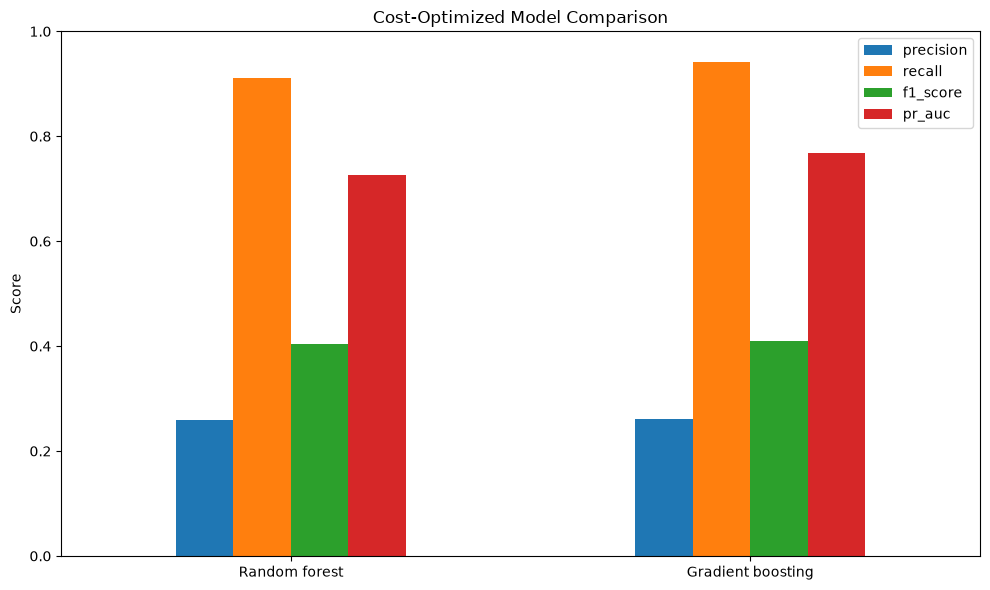

In [ ]:
plot_data = test_results.set_index("model")[
    ["precision", "recall", "f1_score", "pr_auc"]
]

plot_data.plot(
    kind="bar",
    figsize=(10, 6),
)

plt.title("Cost-Optimized Model Comparison")
plt.ylabel("Score")
plt.xlabel("")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(
    FIGURE_DIRECTORY / "cost_optimized_model_comparison.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

## Final interpretation

Gradient boosting was selected as the final model based on the estimated
validation cost. Its optimized decision threshold is 0.07.

On the untouched test set, the model correctly detects 64 of 68 machine
failures, corresponding to a recall of approximately 94.1%. Only four failures
remain undetected. However, the low threshold also produces 181 false
maintenance alarms, resulting in a precision of approximately 26.1%.

Using the assumed costs of EUR 100 per false alarm and EUR 5,000 per missed
failure, the estimated total test cost is EUR 38,100. This is lower than the
estimated cost of the optimized random forest.

Gradient boosting therefore represents the preferred model for this project.
The selected threshold prioritizes failure detection because missed failures
are assumed to be substantially more expensive than unnecessary inspections.
The threshold and cost assumptions would need to be validated using real
industrial maintenance data before deployment.